In [3]:
import numpy as np
import matplotlib.pyplot as plt

# *********
# You should copy your euler and midpoint functions here. 
# We will be comparing to these two existing methods.
# *********

def euler(f,x0,t0,tmax,dt):
    t = np.arange(t0,tmax,dt)# set up the domain based on t0, tmax, and dt
    # next set up an array for x that is the same size a t
    x = np.zeros_like(t)
    x[0] = x0# fill in the initial condition
    for n in range( len(t)-1 ): # think about how far we should loop
        x[n+1] = x[n] + f(t[n],x[n])*dt# advance the solution forward in time with Euler
    return t, x


def midpoint(f,x0,t0,tmax,dt):
    t = np.arange(t0,tmax,dt)# set up the domain based on t0, tmax, and dt
    # next set up an array for x that is the same size a t
    x = np.zeros_like(t)
    x[0] = x0# fill in the initial condition
    for n in range( len(t)-1 ): # think about how far we should loop
        halfX = x[n] + f(t[n],x[n])*dt/2
        x[n+1] = x[n] + f(t[n]+dt/2,halfX)*dt# advance the solution forward in time with Euler
    return t, x




def ode_test(f,x0,t0,tmax,dt,coeffs):
    t = np.arange(t0,tmax+dt,dt) # set up the times
    x = np.zeros(len(t)) # set up the x
    x[0] = x0 # initial condition
    for n in range(len(t)-1):
        k1 = f(t[n],x[n])
        k2 = f(t[n]+dt/2,x[n] + dt/2*k1)
        k3 = f(t[n]+dt/2,x[n]+dt/2*k2)
        k4 = f(t[n]+dt,x[n]+dt*k3)
        estimate_of_slope = coeffs[0]*k1 + coeffs[1]*k2 + coeffs[2]*k3 + coeffs[3]*k4# This is where you get to play
        x[n+1] = x[n] + dt * estimate_of_slope
    return t, x

def thingy(coeffs):
    f = lambda t, x: -(1/3.0)*x + np.sin(t)
    exact = lambda t: (1/10.0)*(19*np.exp(-t/3) + \
                    3*np.sin(t) - \
                    9*np.cos(t))


    x0 = 1 # initial condition
    t0 = 0 # initial time
    tmax = 3 # max time
    # set up blank arrays to keep track of the maximum absolute errorrs
    err_euler = [] 
    err_midpoint = []
    err_ode_test = []
    # Next give a list of Delta t values (what list did we give here)
    H = 10.0**(-np.arange(1,4,1)) 
    for dt in H:
        # Build an euler approximation
        t, xeuler = euler(f,x0,t0,tmax,dt) 
        # Measure the max abs error
        err_euler.append( np.max( np.abs( xeuler - exact(t) ) ) ) 
        # Build a midpoint approximation
        t, xmidpoint = midpoint(f,x0,t0,tmax,dt) 
        # Measure the max abs error
        err_midpoint.append( np.max( np.abs( xmidpoint - exact(t) ) ) ) 
        # Build your new approximation
        t, xtest = ode_test(f,x0,t0,tmax,dt,coeffs) 
        # Measure the max abs error
        err_ode_test.append( np.max( np.abs( xtest - exact(t) ) ) ) 

    # Finally, we make a loglog plot of the errors.  
    # Keep an eye on the slopes since they tell you the order of 
    # the error for the method.
    plt.loglog(H,err_euler,'r*-',
            H,err_midpoint,'b*-',
            H,err_ode_test,'k*-')
    plt.grid()
    plt.legend(['euler','midpoint','test method'])
    plt.show()


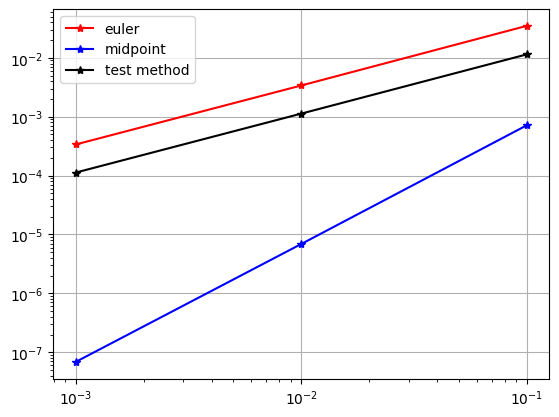

In [ ]:
thingy([1/4,1/4,1/4,1/4]) #Runge-Kurra 4th order ode method
# [1/6,1/3,1/3,1/6]